# Whakaari Dataset

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. The final hourly dataset combines waveform-derived hydrothermal/seismic variables, GNSS deformation, and Open-Meteo weather proxies on a common hourly grid.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    whakaari_observable_metadata,
)

from whakaari_geonet import (
    load_gnss_deformation,
    load_weather_vars,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_analysis_dataframe,
    save_whakaari_analysis_dataset,
    preprocessing_report,
)

from whakaari_plotting_utils import (
    WHAKAARI_ALL_COLS,
    dataset_health_report,
    plot_variable_pdfs,
    distribution_summary,
    plot_whakaari_all_variables_map,
    plot_whakaari_thesis_figures,
    plot_whakaari_loglog_distributions,
)

client = Client("GEONET")

BUFFER_START = (
    pd.Timestamp(WHAKAARI_START, tz="UTC") - pd.Timedelta(days=2)
).strftime("%Y-%m-%d")

## GeoNet and external data

We retrieve GNSS deformation from GeoNet/Tilde and hourly weather variables from Open-Meteo. The final weather proxies are hourly precipitation and hourly atmospheric-pressure drop.

In [2]:
gnss = load_gnss_deformation(
    tilde_data_base_url=TILDE_DATA_URL,
    start=BUFFER_START,
    end=WHAKAARI_END,
)

weather_vars = load_weather_vars(
    lat=WHAKAARI_LAT,
    lon=WHAKAARI_LON,
    start=BUFFER_START,
    end=WHAKAARI_END,
    cache_path="../data/whakaari/whakaari_openmeteo_weather.csv",
    redownload=True, # True to force redownloading, False to use cached dataset
)

## Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a positive tremor-response anomaly variable.

In [3]:
WHAKAARI_WAVEFORM_PKL = "../data/whakaari/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=True, # True will re-download and process waveforms, False will load from pkl
)

done: 2019-10-01
done: 2019-10-02
done: 2019-10-03
done: 2019-10-04
done: 2019-10-05
done: 2019-10-06
done: 2019-10-07
done: 2019-10-08
done: 2019-10-09
done: 2019-10-10
done: 2019-10-11
done: 2019-10-12
done: 2019-10-13
done: 2019-10-14
done: 2019-10-15
done: 2019-10-16
done: 2019-10-17
done: 2019-10-18
done: 2019-10-19
done: 2019-10-20
done: 2019-10-21
done: 2019-10-22
done: 2019-10-23
done: 2019-10-24
done: 2019-10-25
done: 2019-10-26
done: 2019-10-27
done: 2019-10-28
done: 2019-10-29
done: 2019-10-30
done: 2019-10-31
done: 2019-11-01
done: 2019-11-02
done: 2019-11-03
done: 2019-11-04
done: 2019-11-05
done: 2019-11-06
done: 2019-11-07
done: 2019-11-08
done: 2019-11-09
done: 2019-11-10
done: 2019-11-11
done: 2019-11-12
done: 2019-11-13
done: 2019-11-14
done: 2019-11-15
done: 2019-11-16
done: 2019-11-17
done: 2019-11-18
done: 2019-11-19
done: 2019-11-20
done: 2019-11-21
done: 2019-11-22
done: 2019-11-23
done: 2019-11-24
done: 2019-11-25
done: 2019-11-26
done: 2019-11-27
done: 2019-11-

In [4]:
print("Waveform extraction failures:")
display(pd.DataFrame(
    waveform_failures,
    columns=["date", "error"],
))

Waveform extraction failures:


,date,error


## Final hourly dataset

All variables are aligned to a common hourly timeline. Variables are aligned on an hourly grid. Rows containing unresolved missing
values in the selected analysis variables are removed and explicitly reported in the preprocessing audit.

In [6]:
whakaari_master = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    gnss=gnss,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
)

whakaari_dataset = prepare_analysis_dataframe(
    whakaari_master
)

save_whakaari_analysis_dataset(
    whakaari_dataset,
    output_dir="../data/whakaari",
)

WindowsPath('../data/whakaari/whakaari_dataset.csv')

## Distribution diagnostics & preprocessing summary

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


Whakaari analysis dataset
shape: (1733, 7)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_2_5                             0.000000
spectral_log_ratio_4p5_8_over_8_16    0.000000
event_rate_2_5                        0.000000
effect_tremor_5_15                    0.000000
rainfall_mm                           0.000000
pressure_drop                         0.000000
GNSS_deformation_rate                 0.013272
dtype: float64
Whakaari analysis dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
GNSS_deformation_rate,1710.0,-0.000047,0.003557,-8.880000e-03,0.000110,0.008900,-0.213357,72,0.013272
effect_tremor_5_15,1733.0,0.101075,0.327919,0.000000e+00,0.008618,7.939827,15.177260,958,0.000000
event_rate_2_5,1733.0,10.515868,19.842899,0.000000e+00,6.000000,193.000000,5.881431,85,0.000000
hydro_2_5,1733.0,0.000006,0.000120,6.244219e-07,0.000002,0.004080,30.677283,1733,0.000000
pressure_drop,1733.0,-0.002308,0.452483,-1.800000e+00,0.000000,1.800000,0.078751,57,0.000000
rainfall_mm,1733.0,0.098673,0.423874,0.000000e+00,0.000000,6.900000,7.081709,36,0.000000
spectral_log_ratio_4p5_8_over_8_16,1733.0,0.437401,0.332751,-6.421713e-01,0.550124,0.969692,-1.230519,1334,0.000000


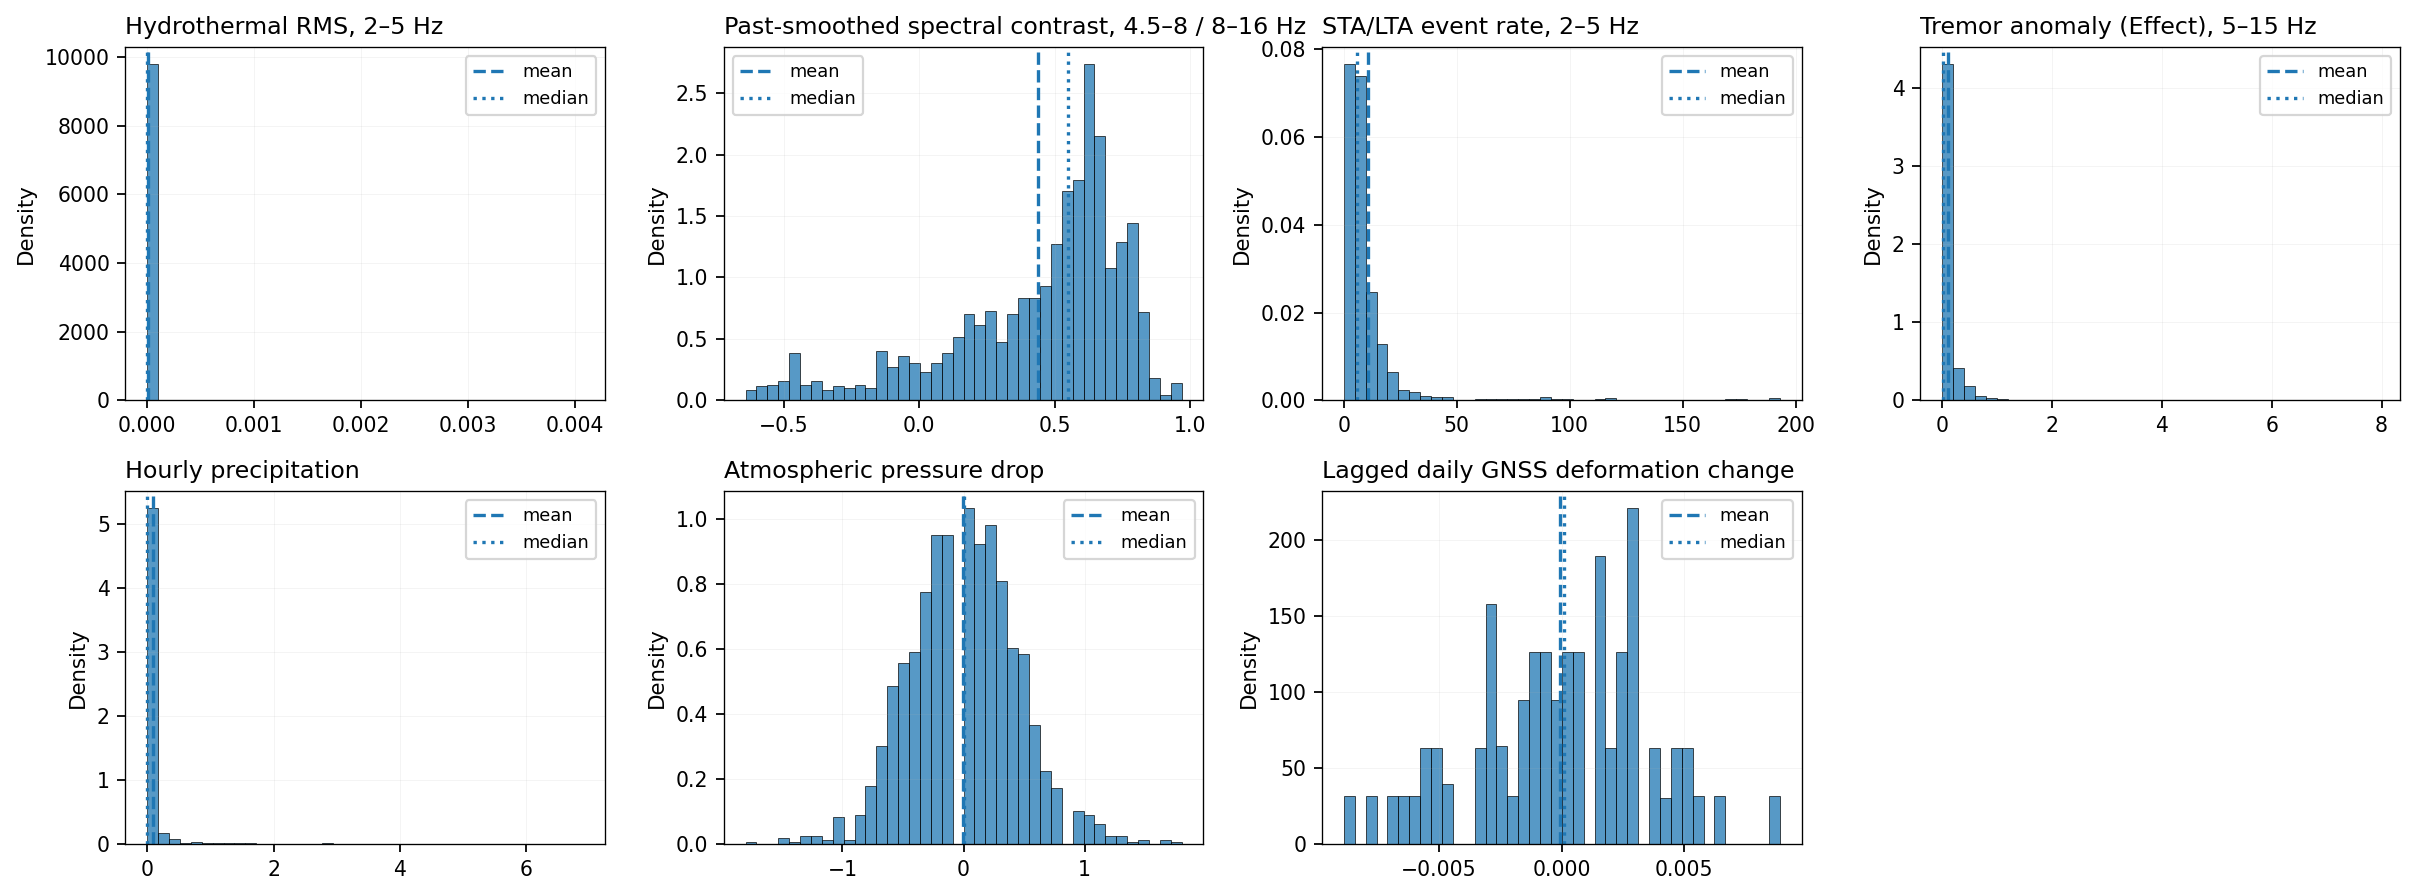

(<Figure size 2432x912 with 8 Axes>,
 array([<Axes: title={'left': 'Hydrothermal RMS, 2–5 Hz'}, ylabel='Density'>,
        <Axes: title={'left': 'Past-smoothed spectral contrast, 4.5–8 / 8–16 Hz'}, ylabel='Density'>,
        <Axes: title={'left': 'STA/LTA event rate, 2–5 Hz'}, ylabel='Density'>,
        <Axes: title={'left': 'Tremor anomaly (Effect), 5–15 Hz'}, ylabel='Density'>,
        <Axes: title={'left': 'Hourly precipitation'}, ylabel='Density'>,
        <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='Density'>,
        <Axes: title={'left': 'Lagged daily GNSS deformation change'}, ylabel='Density'>],
       dtype=object))

In [7]:
dataset_health_report(whakaari_dataset, "Whakaari analysis dataset")

display(distribution_summary(whakaari_dataset, "Whakaari analysis dataset"))

plot_variable_pdfs(
    whakaari_dataset,
    name="",
    cols=WHAKAARI_ALL_COLS,
    bins=40,
    filename="whakaari_pdf"
)

In [8]:
WHAKAARI_WAVEFORM_COLUMNS = [
    "hydro_2_5",
    "spectral_log_ratio_4p5_8_over_8_16",
    "event_rate_2_5",
    "effect_tremor_5_15",
]

waveform_correlations = (
    whakaari_dataset[WHAKAARI_WAVEFORM_COLUMNS]
    .corr(method="spearman")
)

display(waveform_correlations)

,hydro_2_5,spectral_log_ratio_4p5_8_over_8_16,event_rate_2_5,effect_tremor_5_15
hydro_2_5,1.000000,0.577905,0.474492,0.187366
spectral_log_ratio_4p5_8_over_8_16,0.577905,1.000000,0.290166,-0.088955
event_rate_2_5,0.474492,0.290166,1.000000,0.090729
effect_tremor_5_15,0.187366,-0.088955,0.090729,1.000000


In [9]:
preprocessing_summary = preprocessing_report(
    rawest_df=whakaari_master,
    prepared_df=whakaari_dataset,
)


Preprocessing summary
---------------------
Rows before preprocessing: 1752
Rows after preprocessing:  1733
Rows dropped:              19

Dropped timestamps:
  2019-10-01 00:00:00+00:00
  2019-10-01 01:00:00+00:00
  2019-10-01 02:00:00+00:00
  2019-10-01 03:00:00+00:00
  2019-10-01 04:00:00+00:00
  2019-10-01 05:00:00+00:00
  2019-10-01 06:00:00+00:00
  2019-10-01 07:00:00+00:00
  2019-10-01 08:00:00+00:00
  2019-10-01 09:00:00+00:00
  2019-10-01 10:00:00+00:00
  2019-10-01 11:00:00+00:00
  2019-11-18 23:00:00+00:00
  2019-11-19 00:00:00+00:00
  2019-11-19 01:00:00+00:00
  2019-11-19 02:00:00+00:00
  2019-11-19 03:00:00+00:00
  2019-11-19 04:00:00+00:00
  2019-11-19 05:00:00+00:00

Variables with preprocessing changes:


,variable,status,missing_before,missing_after,filled_from_nan,changed_existing,lost_by_dropped_rows
0,GNSS_deformation_rate,kept,23,23,0,0,19
1,effect_tremor_5_15,kept,16,0,0,0,3
2,event_rate_2_5,kept,4,0,0,0,15
3,hydro_2_5,kept,4,0,0,0,15
4,pressure_drop,kept,0,0,0,0,19
5,rainfall_mm,kept,0,0,0,0,19
6,spectral_log_ratio_4p5_8_over_8_16,kept,6,0,0,0,13


### Whakaari raw-variable log-log distributions

a visual diagnostic for scale, tails, and zero inflation.

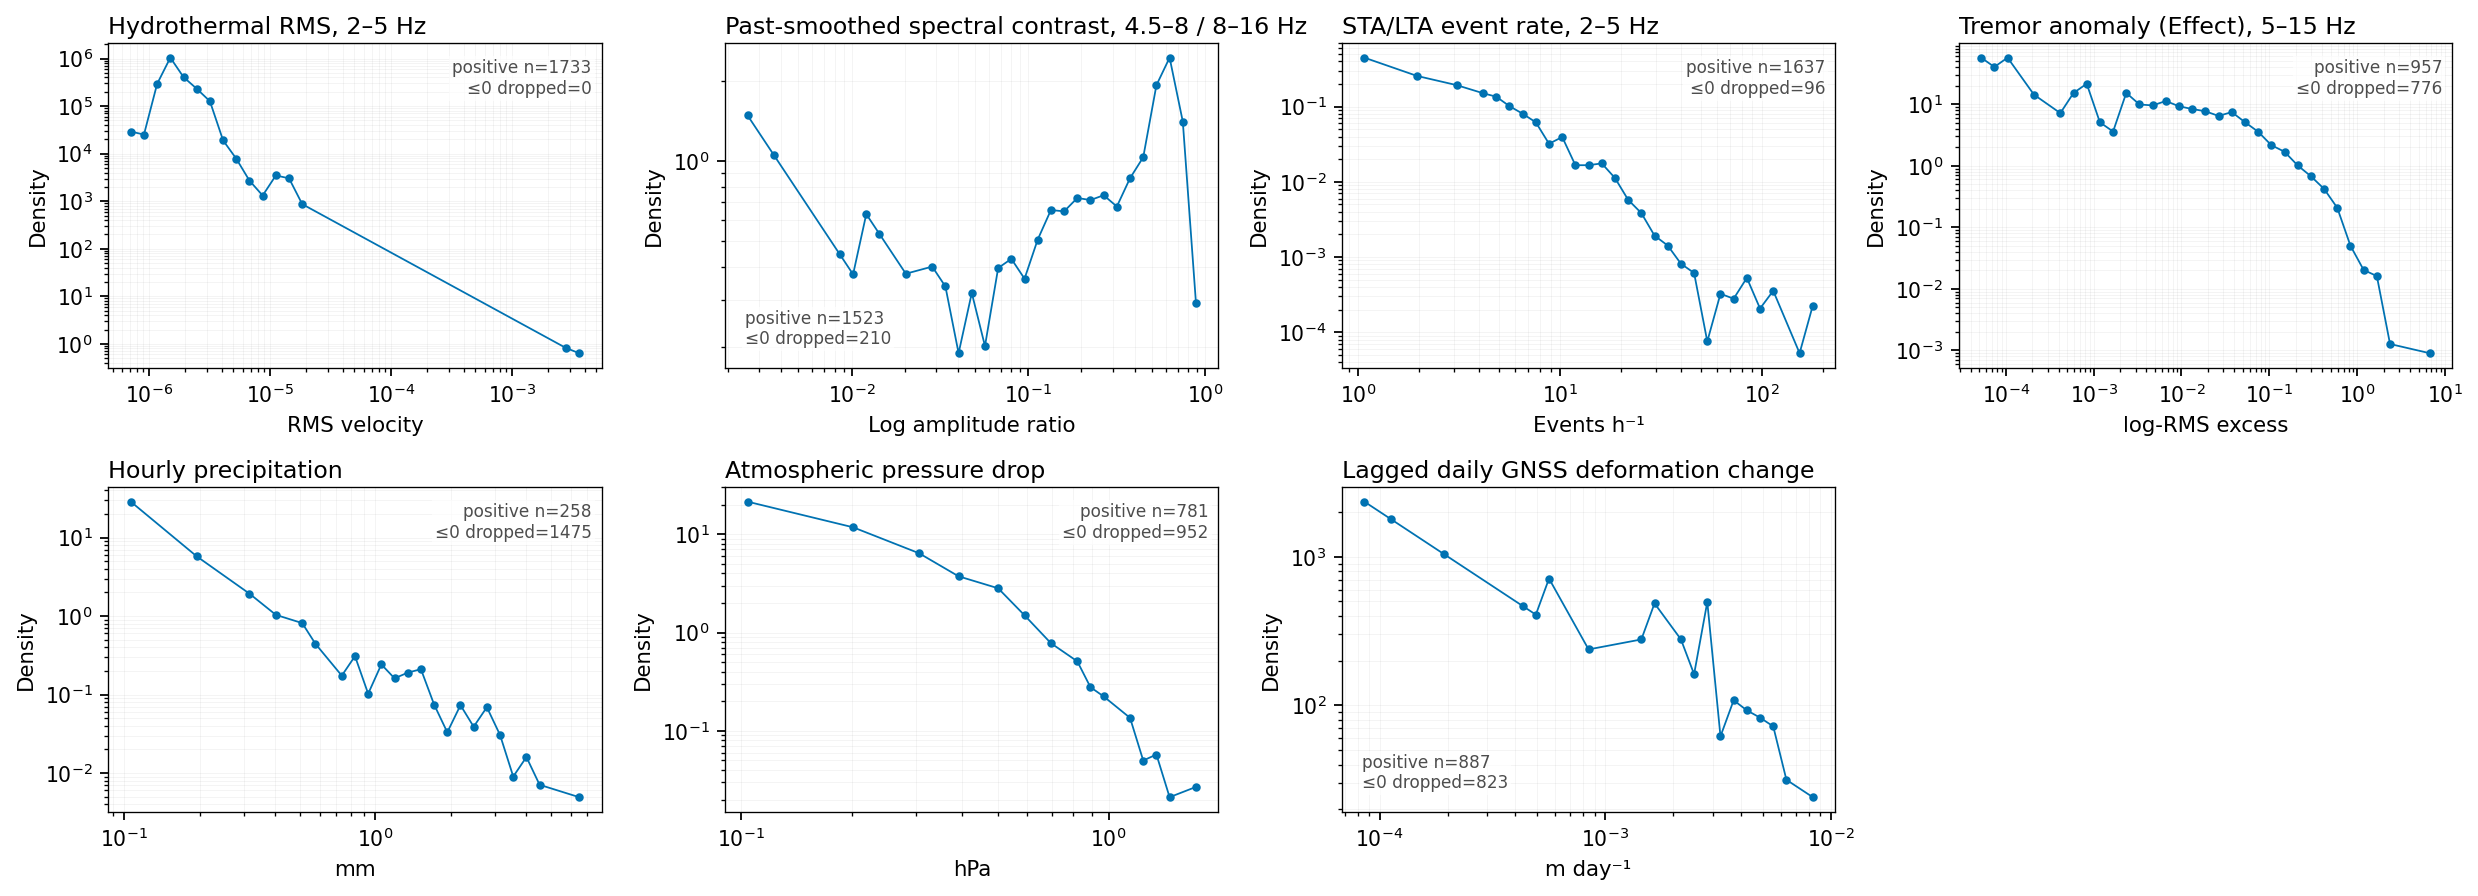

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_dropped,positive_fraction,min_positive,max_positive,n_unique_positive
0,hydro_2_5,1733,1733,0,1.000000,6.244219e-07,0.004080,1733
1,spectral_log_ratio_4p5_8_over_8_16,1733,1523,210,0.878823,2.363047e-03,0.969692,1176
2,event_rate_2_5,1733,1637,96,0.944605,1.000000e+00,193.000000,84
3,effect_tremor_5_15,1733,957,776,0.552222,4.420419e-05,7.939827,957
4,rainfall_mm,1733,258,1475,0.148875,1.000000e-01,6.900000,35
5,pressure_drop,1733,781,952,0.450664,1.000000e-01,1.800000,29
6,GNSS_deformation_rate,1710,887,823,0.518713,8.000000e-05,0.008900,36


In [10]:
fig, axes, whakaari_loglog_report = plot_whakaari_loglog_distributions(
    whakaari_dataset.reset_index(),
    save_dir="figures",
)

display(whakaari_loglog_report)

## Final hourly dataset with event marker

The final variables are plotted with the eruption time marked. To assess whether the causal-analysis window and variables are physically meaningful.

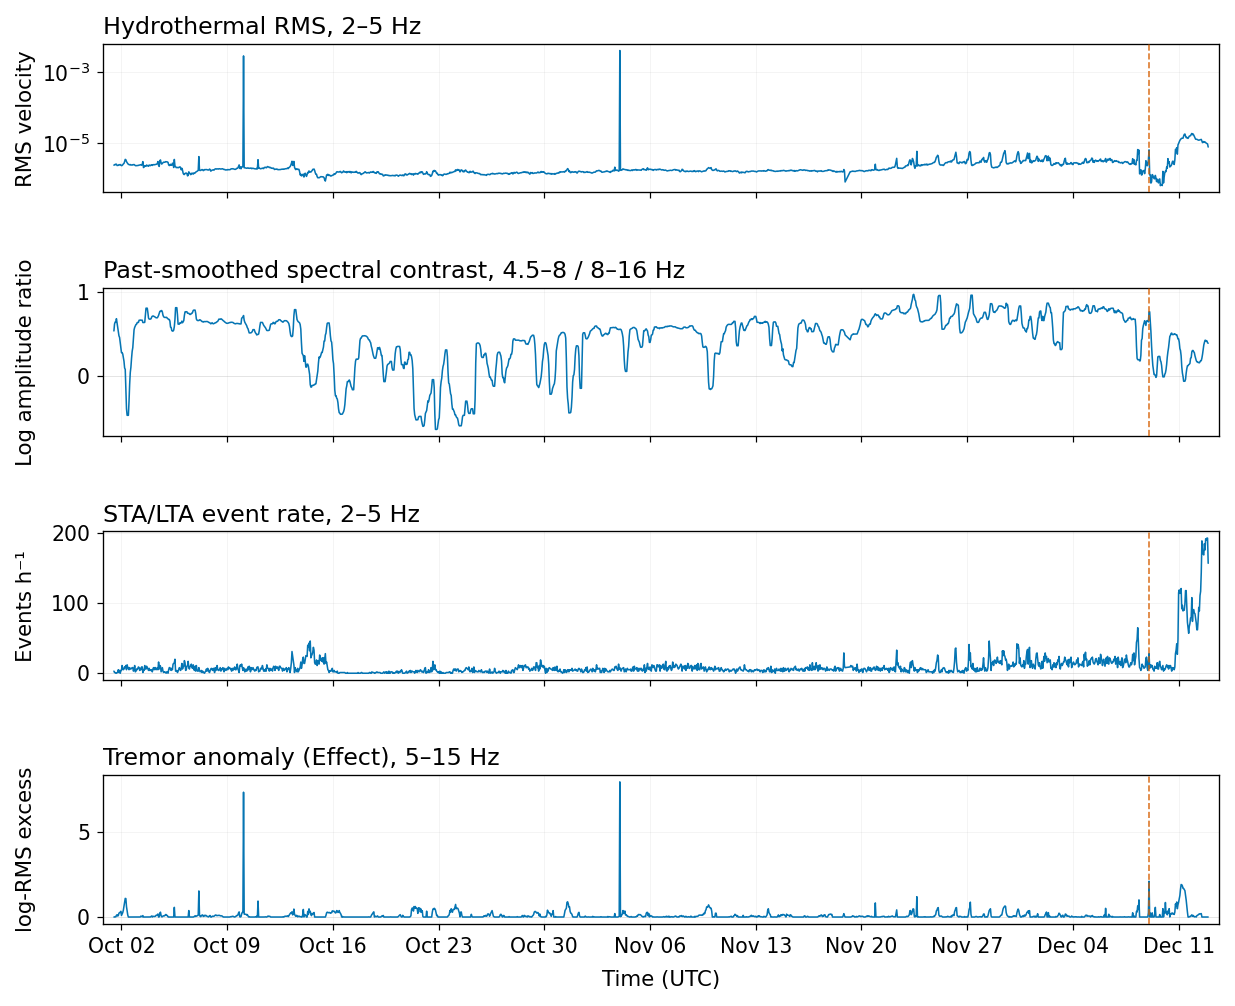

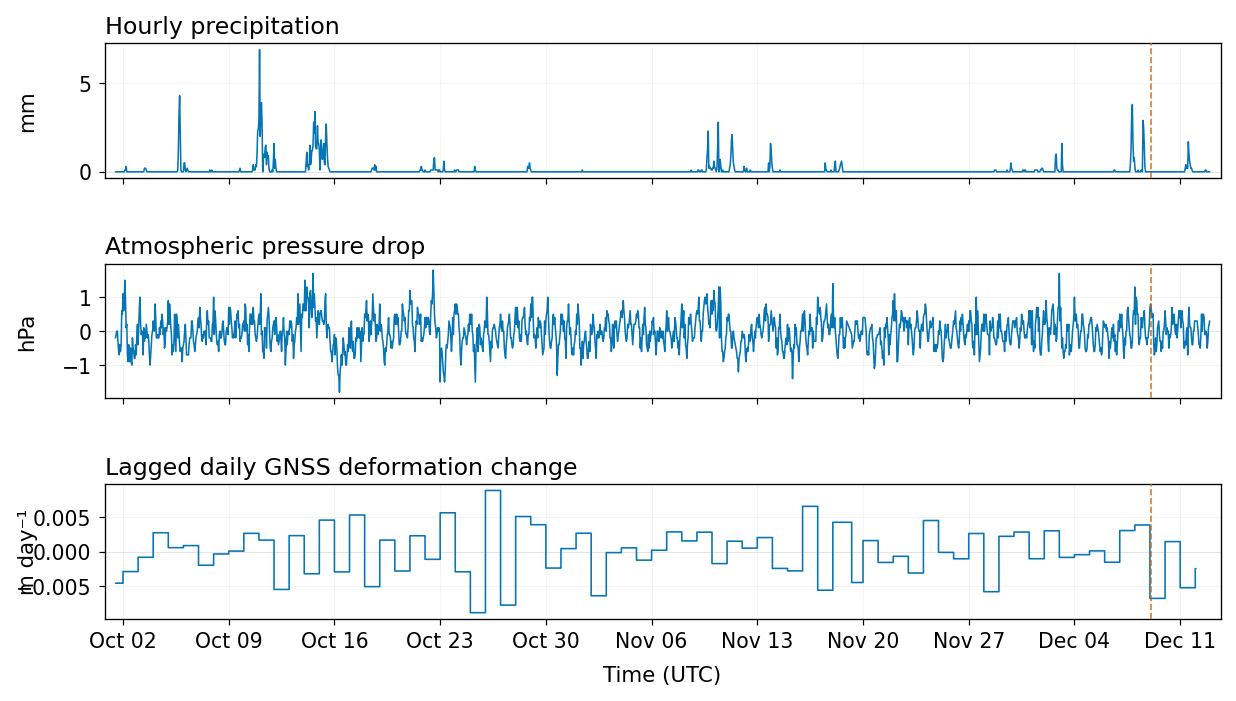

((<Figure size 1280x988.8 with 4 Axes>,
  array([<Axes: title={'left': 'Hydrothermal RMS, 2–5 Hz'}, ylabel='RMS velocity'>,
         <Axes: title={'left': 'Past-smoothed spectral contrast, 4.5–8 / 8–16 Hz'}, ylabel='Log amplitude ratio'>,
         <Axes: title={'left': 'STA/LTA event rate, 2–5 Hz'}, ylabel='Events h⁻¹'>,
         <Axes: title={'left': 'Tremor anomaly (Effect), 5–15 Hz'}, xlabel='Time (UTC)', ylabel='log-RMS excess'>],
        dtype=object)),
 (<Figure size 1280x646.4 with 3 Axes>,
  array([<Axes: title={'left': 'Hourly precipitation'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'Lagged daily GNSS deformation change'}, xlabel='Time (UTC)', ylabel='m day⁻¹'>],
        dtype=object)))

In [12]:
plot_whakaari_thesis_figures(
    csv_path="../data/whakaari/whakaari_dataset.csv",
    eruption_time=WHAKAARI_ERUPTION_TIME,
    save_dir="figures",
    include_titles=False,
)

## Geographic Visualization

,Source,Source ID,Variables,Internal names
0,Open-Meteo,WHAKAARI_OPENMETEO_PROXY,Hourly precipitation; Atmospheric pressure drop,"rainfall_mm, pressure_drop"
1,RGWC–RGWI GNSS,RGWC_RGWI,Lagged daily GNSS deformation change,GNSS_deformation_rate
2,WSRZ,WSRZ,"Hydrothermal tremor RMS, 2–5 Hz; Past-smoothed...","hydro_2_5, spectral_log_ratio_4p5_8_over_8_16,..."


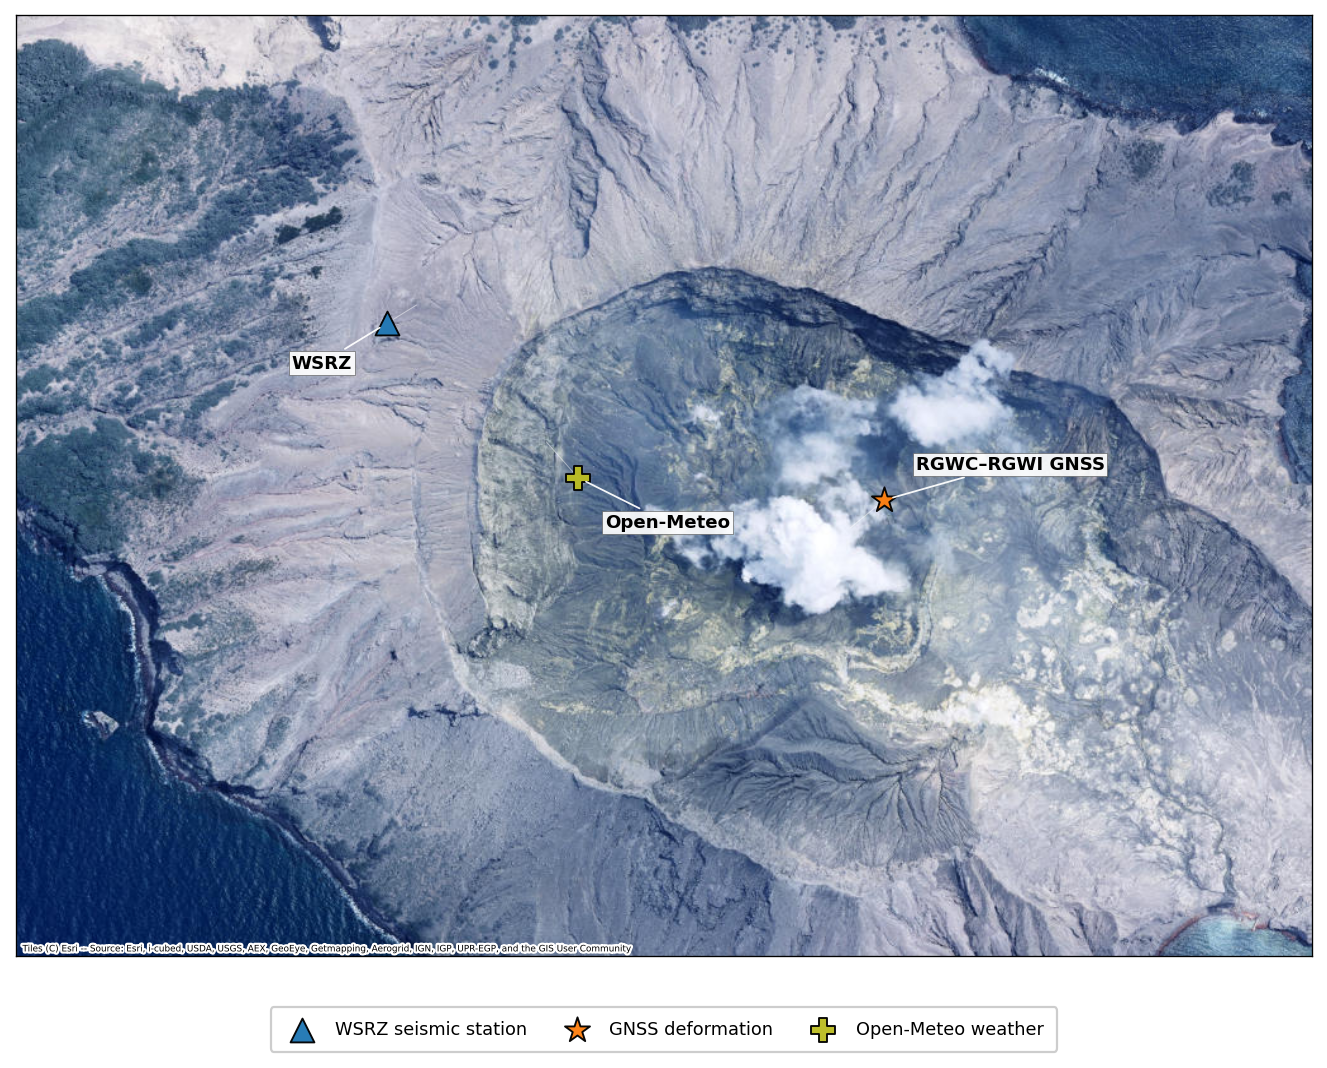

In [13]:
whakaari_meta = whakaari_observable_metadata()

fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    metadata=whakaari_meta,
    satellite=True, # True for satellite imagery
    save_dir="figures",
    filename="whakaari_map",
)

whakaari_variable_table